In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

       Target_Method     N  Total Time (ms)  ms per item
0            IsEqual     1         0.000140     0.000140
1            IsEqual    10         0.001659     0.000166
2            IsEqual   100         0.017157     0.000172
3            IsEqual  1000         0.169019     0.000169
4          IsGreater     1         0.000180     0.000180
5          IsGreater    10         0.002112     0.000211
6          IsGreater   100         0.021540     0.000215
7          IsGreater  1000         0.217417     0.000217
8   IsGreaterOrEqual     1         0.000178     0.000178
9   IsGreaterOrEqual    10         0.002057     0.000206
10  IsGreaterOrEqual   100         0.021503     0.000215
11  IsGreaterOrEqual  1000         0.214970     0.000215
12           IsLower     1         0.000178     0.000178
13           IsLower    10         0.002074     0.000207
14           IsLower   100         0.021511     0.000215
15           IsLower  1000         0.219204     0.000219
16    IsLowerOrEqual     1     

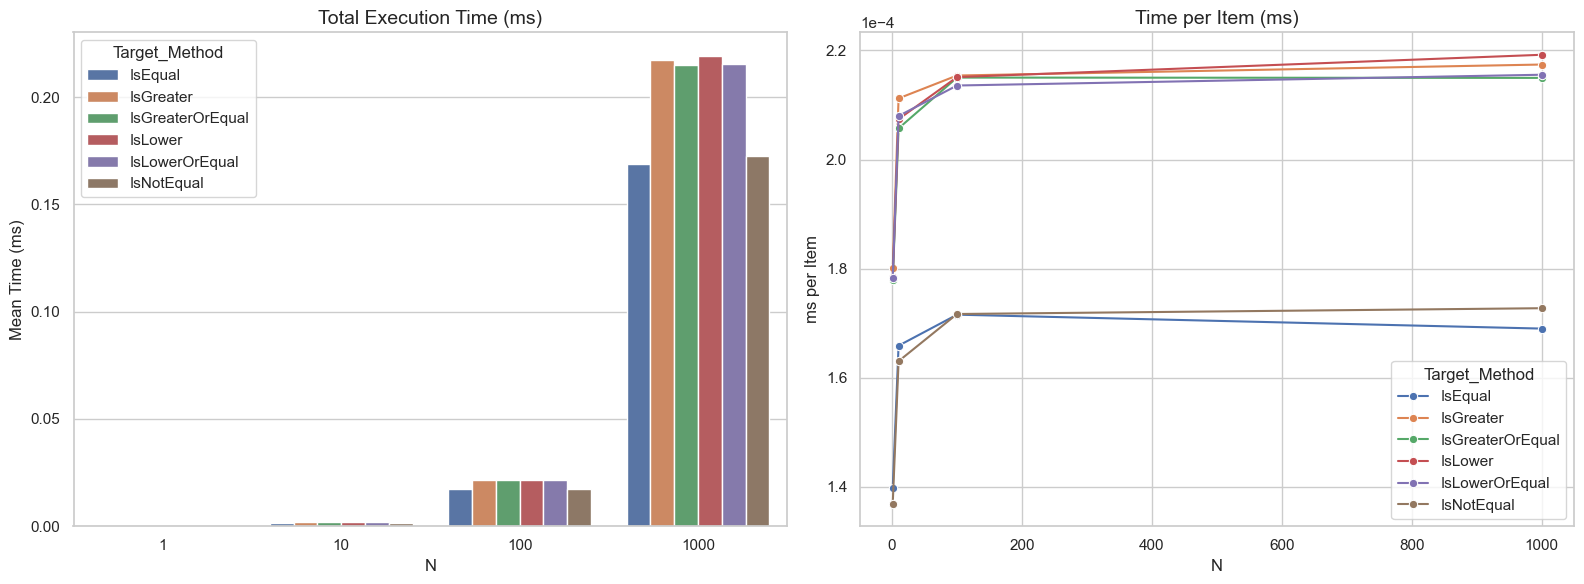

In [3]:
# Load data
df = pd.read_csv('data/filter/filter_double_performance_data.csv')

# Extract N from Params
df['N'] = df['Params'].str.extract(r'N=(\d+)').astype(int)

# Filter for Workload Result iterations
df_res = df[(df['Measurement_IterationMode'] == 'Workload') & (df['Measurement_IterationStage'] == 'Result')]

# Aggregate means
summary = df_res.groupby(['Target_Method', 'N'])['Measurement_Value'].mean().reset_index()

# Convert ns to ms
summary['Total Time (ms)'] = summary['Measurement_Value'] / 1_000_000

# Calculate ms per item
summary['ms per item'] = summary['Total Time (ms)'] / summary['N']

# Set plotting style
sns.set_theme(style="whitegrid")

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Total Execution Time
sns.barplot(
    data=summary,
    x='N',
    y='Total Time (ms)',
    hue='Target_Method',
    ax=axes[0]
)
axes[0].set_title('Total Execution Time (ms)', fontsize=14)
axes[0].set_ylabel('Mean Time (ms)')
axes[0].set_ylim(0)

# Subplot 2: ms per item
# Using a log scale or scientific notation might be necessary given the small values
sns.lineplot(
    data=summary,
    x='N',
    y='ms per item',
    hue='Target_Method',
    marker='o',
    ax=axes[1]
)
axes[1].set_title('Time per Item (ms)', fontsize=14)
axes[1].set_ylabel('ms per Item')
#axes[1].set_xscale('log') # Better for visualizing across magnitudes of N
axes[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))

plt.tight_layout()
plt.savefig('images/filter/filter_double_performance.png')

# Display the summary for the response
print(summary[['Target_Method', 'N', 'Total Time (ms)', 'ms per item']])

      Target_Method      N  Total Time (ms)  ms per item
0     EqualsOrdinal    100         0.000105     0.000001
1     EqualsOrdinal   1000         0.002574     0.000003
2     EqualsOrdinal  10000         0.014652     0.000001
3     EqualsOrdinal  20000         0.030490     0.000002
4     EqualsOrdinal  30000         0.046008     0.000002
5  NotEqualsOrdinal    100         0.000105     0.000001
6  NotEqualsOrdinal   1000         0.002592     0.000003
7  NotEqualsOrdinal  10000         0.014841     0.000001
8  NotEqualsOrdinal  20000         0.028358     0.000001
9  NotEqualsOrdinal  30000         0.041960     0.000001


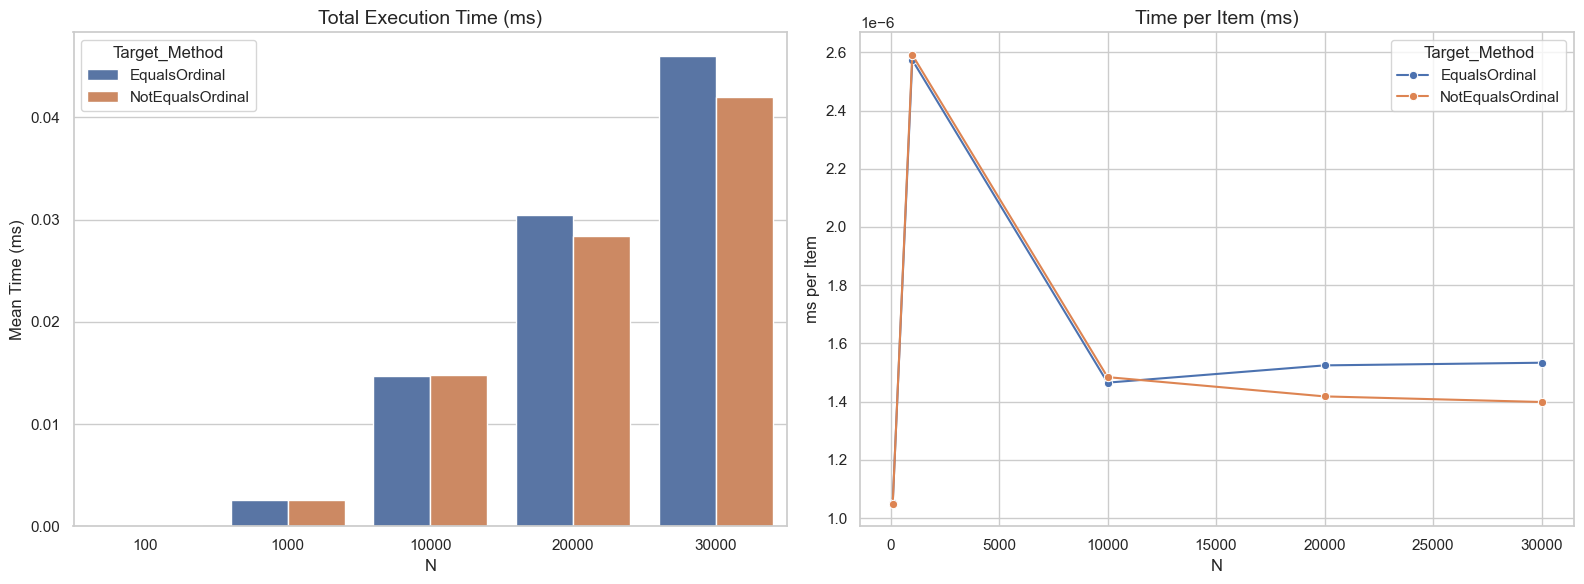

In [13]:
    # Load data
df = pd.read_csv('data/filter/filter_string_performance_data.csv')

# Extract N from Params
df['N'] = df['Params'].str.extract(r'N=(\d+)').astype(int)

# Filter for Workload Result iterations
df_res = df[(df['Measurement_IterationMode'] == 'Workload') & (df['Measurement_IterationStage'] == 'Result')]

# Aggregate means
summary = df_res.groupby(['Target_Method', 'N'])['Measurement_Value'].mean().reset_index()

# Convert ns to ms
summary['Total Time (ms)'] = summary['Measurement_Value'] / 1_000_000

# Calculate ms per item
summary['ms per item'] = summary['Total Time (ms)'] / summary['N']

# Set plotting style
sns.set_theme(style="whitegrid")

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Total Execution Time
sns.barplot(
    data=summary,
    x='N',
    y='Total Time (ms)',
    hue='Target_Method',
    ax=axes[0]
)
axes[0].set_title('Total Execution Time (ms)', fontsize=14)
axes[0].set_ylabel('Mean Time (ms)')
axes[0].set_ylim(0)

# Subplot 2: ms per item
# Using a log scale or scientific notation might be necessary given the small values
sns.lineplot(
    data=summary,
    x='N',
    y='ms per item',
    hue='Target_Method',
    marker='o',
    ax=axes[1]
)
axes[1].set_title('Time per Item (ms)', fontsize=14)
axes[1].set_ylabel('ms per Item')
#axes[1].set_xscale('log') # Better for visualizing across magnitudes of N
axes[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))

plt.tight_layout()
plt.savefig('images/filter/filter_string_performance.png')

# Display the summary for the response
print(summary[['Target_Method', 'N', 'Total Time (ms)', 'ms per item']])